## WeatherAnalyze

Ett program där användaren väljer en av tre städer och får en sjudagarsprognos för vädret. Väderdata analyseras och visas sedan i diagram. Datan rensas och normaliseras också som förberedelse för eventuell framtida användning i en AI-modell.

## Importer

Importerar nödvändiga bibliotek för programmet.

In [40]:
import requests
import json
import matplotlib.pyplot as plt
from datetime import datetime

print("Nödvändiga importer laddade!")


Nödvändiga importer laddade!


## Städernas koordinater

Dictionaryn `cities` kopplar varje valbar stad till latitud och longitud. Koordinaterna används för att hämta väderdata från API:t.

In [41]:
# Dictionary med koordinater för de valbara städerna inför anrop till API

cities = {
    "Stockholm": [59.33, 18.07],
    "Göteborg": [57.71, 11.97],
    "Malmö": [55.61, 13.00]
}


print(f"Skriver ut testkoordinater för Sthlm: {cities['Stockholm']}")

Skriver ut testkoordinater för Sthlm: [59.33, 18.07]


## Val av stad

Funktionen `get_city()` frågar efter en stad tills användaren gör ett giltigt val och returnerar stadens namn.

In [42]:
def get_city():
    print("Välj stad för att hämta en sjudagarsprognos:")
    print("1. Stockholm")
    print("2. Göteborg")
    print("3. Malmö\n")

    while True:
        choice = input("Ange vilken stad du vill hämta prognosen ifrån (1-3):")
        
        if choice == "1":
            return "Stockholm"
        elif choice == "2":
            return "Göteborg"
        elif choice == "3":
            return "Malmö"
        else:
            print("Du måste välja en siffra (1-3)!")

# Hämtar koordinaterna för vald stad från dictionaryn och packar upp dem i latitude och longitude
city = get_city()
latitude, longitude = cities[city]

print(f"Vald stad: {city}")
print(f"Koordinater: {latitude}, {longitude}")

    

Välj stad för att hämta en sjudagarsprognos:
1. Stockholm
2. Göteborg
3. Malmö

Vald stad: Stockholm
Koordinater: 59.33, 18.07


## Val av vindinformation

Funktionen `get_detailed_info()` returnerar `True` eller `False` beroende på om användaren vill visa vindinformation.

In [43]:
def get_detailed_info():
    while True:
        extra_choice = input("Vill du visa detaljerad information om vind? (j/n): ")
        if extra_choice == "j":
            return True
        elif extra_choice == "n":
            return False
        else:
            print("Du måste välja: (j/n)! ")

# Kör funktionen och sparar booleskt värde i variabeln detailed_info
detailed_info = get_detailed_info()

print(f"Visa vindinformation: {detailed_info}")

Visa vindinformation: True


## API-anrop

Funktionen `get_weather()` använder `requests` för att hämta en väderprognos för sju dagar från Open-Meteo utifrån stadens koordinater. Den returnerar temperaturer, tidpunkter och vindhastigheter. Med `try/except` hanteras fel vid API-anropet och saknade fält i svaret.

In [44]:
def get_weather(latitude, longitude):
    url = "https://api.open-meteo.com/v1/forecast"

    # Parametrar som skickas med i API-anropet
    weather_parameters = {
        "latitude": latitude,
        "longitude": longitude,
        "hourly": "temperature_2m,wind_speed_10m",
        "forecast_days": 7,
        "timezone": "Europe/Stockholm"
    }

    try:
        # Skickar API-anropet kontrollerar HTTP-statuskoden och omvandlar JSON-svaret till en Python-dictionary
        response = requests.get(url, params=weather_parameters, timeout=10)
        response.raise_for_status()
        data = response.json()

        # Hämtar temperatur, tid och vind från den nästlade datan
        temperature = data["hourly"]["temperature_2m"]
        weather_time = data["hourly"]["time"]
        wind = data["hourly"]["wind_speed_10m"]
    
        return temperature, weather_time, wind

    # Hanterar eventuella fel vid API-anropet eller om förväntad data saknas
    except requests.exceptions.RequestException:
        print("Kunde inte hämta väderdata från API.")
        return None, None, None

    except KeyError:
        print("Förväntad data saknas i API-svaret.")
        return None, None, None

# Hämtar prognosen och tilldelar listorna med temperaturer, tidpunkter och vindhastigheter till varsin variabel 
temperature, weather_time, wind = get_weather(latitude, longitude)

# Kontrollerar att väderdata har hämtats och visar exempel på resultatet.
if temperature is not None:
    print("Api-anrop lyckades!")
    print(f"Hämtade {len(temperature)} temperaturvärden.")
    print(f"Första tidpunkten: {weather_time[0]}")
    print(f"Första temperaturen: {temperature[0]} °C")
    



Api-anrop lyckades!
Hämtade 168 temperaturvärden.
Första tidpunkten: 2026-10-02T00:00
Första temperaturen: 13.5 °C


## Klasser och arv

Klassen `Weather` lagrar stad, temperatur och tid. Barnklassen `DetailedWeather` ärver dessa attribut via `super()` och lägger till vindhastighet. Båda använder `__str__()` för att visa informationen som text.

In [45]:

# Skapar en Weather-klass
class Weather:
    def __init__(self, city, temperature, weather_time):
        self.city = city
        self.temperature = temperature
        self.time = weather_time

    def __str__(self):
        return f"Temperaturen i {self.city} är {self.temperature}°C, tidpunkt: {self.time}"

# DetailedWeather ärver från Weather och anropar föräldraklassens konstruktor som initierar de ärvda attributen
class DetailedWeather(Weather):
    def __init__(self, city, temperature, weather_time, wind):
        super().__init__(city, temperature, weather_time)
        self.wind = wind

    def __str__(self):
        return f"Temperaturen i {self.city} är {self.temperature}°C, tidpunkt: {self.time}, vindhastighet: {self.wind} km/h."

# Skapar exempel på föräldraklass och barnklass och skriver ut dem
weather_example = Weather("Stockholm", 20.5, "12:00")
detailed_example = DetailedWeather("Stockholm", 20.5, "12:00", 4.2)

print("Skriver ut exempel på föräldraklass och barnklass:\n")
print(f"Föräldraklass: {weather_example}")
print(f"Barnklass: {detailed_example}")


Skriver ut exempel på föräldraklass och barnklass:

Föräldraklass: Temperaturen i Stockholm är 20.5°C, tidpunkt: 12:00
Barnklass: Temperaturen i Stockholm är 20.5°C, tidpunkt: 12:00, vindhastighet: 4.2 km/h.


## Skapa väderobjekt

En loop skapar ett väderobjekt för varje tidpunkt och sparar det i `weather_forecast`. Om användaren valt vindinformation används `DetailedWeather`, annars `Weather`.

In [46]:
# Skapar en tom lista som ska fyllas med väderobjekt
weather_forecast = []

# Skapar ett väderobjekt för varje prognostid och lägger till vinddata om användaren valt detaljerad information 
if temperature is not None:
    for i in range(len(weather_time)):
        if detailed_info:
            weather_object = DetailedWeather(
                city,
                temperature[i],
                weather_time[i],
                wind[i]
            )
        else:
            weather_object = Weather(
                city,
                temperature[i],
                weather_time[i]
            )

        # Lägger till väderobjekten i en lista  
        weather_forecast.append(weather_object)

    print(f"Antal väderobjekt i prognosen: {len(weather_forecast)}")
    print(f"Exempel på väderobjekt: {weather_forecast[0]}")



Antal väderobjekt i prognosen: 168
Exempel på väderobjekt: Temperaturen i Stockholm är 13.5°C, tidpunkt: 2026-10-02T00:00, vindhastighet: 9.4 km/h.


## Spara väderdata

Funktionen `save_weather()` omvandlar väderobjekten till dictionaries och sparar dem i en JSON-fil. Vid varje körning ersätts filens innehåll med den senast hämtade prognosen och metadata. JSON-filen innehåller också metadata om källa, skapandedatum och GDPR-status.

In [47]:
def save_weather(weather_forecast):
    weather_data = []

    # Omvandlar varje väderobjekt till en dictionary och lägger till vinddata om detaljerade objekt.
    for weather_object in weather_forecast:
        data = {
            "city": weather_object.city,
            "temperature": weather_object.temperature,
            "time": weather_object.time
        }

        if isinstance(weather_object, DetailedWeather):
            data["wind"] = weather_object.wind

        # Lägger till dictionaries i en lista
        weather_data.append(data)

    # Skapar en dictionary med metadata och listan med väderdata
    data_with_metadata = {
        "source": "Open-Meteo API",
        "created": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "contains_personal_data": False,
        "data": weather_data
    }

    # Sparar väderdata med metadata i en JSON-fil och hanterar eventuella fel vid filskrivning
    try:
        with open("weather_data.json", "w", encoding="utf-8") as file:
            json.dump(data_with_metadata, file, indent=4, ensure_ascii=False)

        print("Den hämtade datan har sparats i JSON-filen!")

    except OSError:
        print("Kunde inte skriva till JSON-filen.")
        return

# Kontrollerar att väderdata har hämtats innan den sparas i en JSON-fil
if temperature is not None:
    save_weather(weather_forecast)


Den hämtade datan har sparats i JSON-filen!


## Analys av väderdata

Funktionerna beräknar och skriver ut lägsta, högsta och genomsnittliga temperatur och vindhastighet för sjudagarsperioden.

In [48]:
# Analyserar temperaturdata och skriver ut minsta, största och medeltemperatur
def analyze_temperature(temperature, city):
    min_temperature = min(temperature)
    max_temperature = max(temperature)
    avg_temperature = sum(temperature) / len(temperature)

    print(f"Kortfattad analys av sjudagarsprognosen för temperatur i {city}: ")
    print(f"Lägsta temperatur: {min_temperature}°C")
    print(f"Högsta temperatur: {max_temperature}°C")
    print(f"Medeltemperatur: {avg_temperature:.1f}°C")

if temperature is not None:
    analyze_temperature(temperature, city)

# Analyserar vinddata och skriver ut minsta, största och medelvindhastighet
def analyze_wind(wind, city):
    min_wind = min(wind)
    max_wind = max(wind)
    avg_wind = sum(wind) / len(wind)

    print(f"\nKortfattad analys av sjudagarsprognosen för vind i {city}:  ")
    print(f"Lägsta vindhastighet: {min_wind} km/h")
    print(f"Högsta vindhastighet: {max_wind} km/h")
    print(f"Medelvindhastighet: {avg_wind:.1f} km/h")

# Kontrollerar att användaren valt detaljerad information och att vinddata har hämtats innan den analyseras
if detailed_info and wind is not None:
    analyze_wind(wind, city)

Kortfattad analys av sjudagarsprognosen för temperatur i Stockholm: 
Lägsta temperatur: 7.6°C
Högsta temperatur: 18.1°C
Medeltemperatur: 12.7°C

Kortfattad analys av sjudagarsprognosen för vind i Stockholm:  
Lägsta vindhastighet: 1.0 km/h
Högsta vindhastighet: 25.5 km/h
Medelvindhastighet: 13.9 km/h


## Visualisering av väderdata

Funktionerna använder `matplotlib` för att visa temperatur och vindhastighet över tid. Vinddiagrammet visas bara om användaren valt vindinformation.


Visar diagram över sjudagarsprognosen för Stockholm:
 


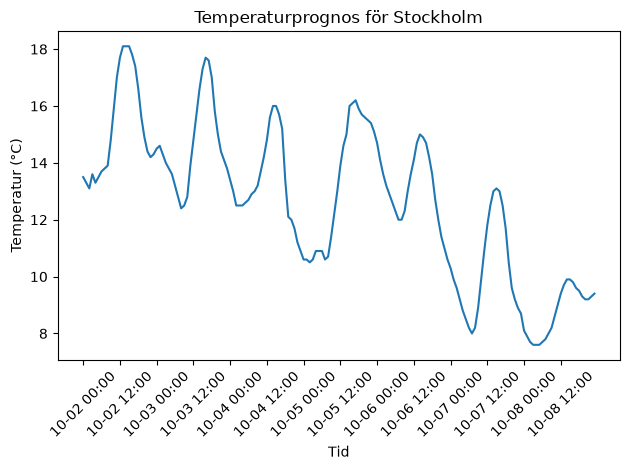

Visar diagram över sjudagarsprognosen för vind i Stockholm:
 


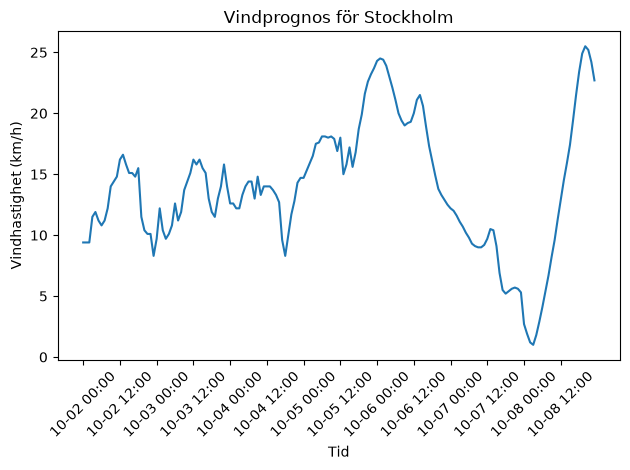

In [ ]:
# Plottar temperaturdata i ett diagram med hjälp av matplotlib och visar det i ett separat fönster
def plot_temperature(weather_time, temperature, city):
    time_labels = []

    # Formaterar varje tidpunkt som månad-dag och klockslag och sparar den i time_labels
    for time in weather_time:
        time_labels.append(time[5:16].replace("T", " "))

    plt.plot(time_labels, temperature)

    plt.xlabel("Tid")
    plt.ylabel("Temperatur (°C)")
    plt.title(f"Temperaturprognos för {city}")

    plt.xticks(time_labels[::12], rotation=45)
    plt.tight_layout()
    plt.show()

# Plottar vinddata i ett diagram med hjälp av matplotlib och visar det i ett separat fönster
def plot_wind(weather_time, wind, city):
    time_labels = []

    # Formaterar varje tidpunkt som månad-dag och klockslag och sparar den i time_labels
    for time in weather_time:
        time_labels.append(time[5:16].replace("T", " "))

    plt.plot(time_labels, wind)

    plt.xlabel("Tid")
    plt.ylabel("Vindhastighet (km/h)")
    plt.title(f"Vindprognos för {city}")

    plt.xticks(time_labels[::12], rotation=45)
    plt.tight_layout()
    plt.show()

# Kontrollerar att väderdata har hämtats innan diagrammen plottas
if temperature is not None:
    print(f"\nVisar diagram över sjudagarsprognosen för {city}:\n ")
    plot_temperature(weather_time, temperature, city)

    # Om användaren valt detaljerad information plottas även vinddiagrammet
    if detailed_info:
        print(f"Visar diagram över sjudagarsprognosen för vind i {city}:\n ")
        plot_wind(weather_time, wind, city)

## Förberedelse av data för AI-modell

Vid eventuell framtida användning av datan i en AI-modell så är det bra att rensa bort orimliga värden för att undvika att felaktig data påverkar modellen.

Därefter normaliseras datan till värden mellan 0 och 1. Det är särskilt användbart när man har flera numeriska features (indata) med olika skalor.

In [ ]:
# Tar bort värden som ej är nummer och extremvärden för temperatur utanför -40 till 40 °C
def clean_temperature_data(temperature):
    cleaned_temperature = []

    for value in temperature:
        if isinstance(value, (int, float)) and -40 <= value <= 40:
            cleaned_temperature.append(value)

    return cleaned_temperature

# Tar bort värden som ej är nummer och extremvärden för vind utanför 0 till 150 km/h
def clean_wind_data(wind):
    cleaned_wind = []

    for value in wind:
        if isinstance(value, (int, float)) and 0 <= value <= 150:
            cleaned_wind.append(value)

    return cleaned_wind


# Kontrollerar att väderdata har hämtats innan den rensas
if temperature is not None:
    cleaned_temperature = clean_temperature_data(temperature)

    print(f"Antal temperaturvärden före rensning: {len(temperature)}")
    print(f"Antal temperaturvärden efter rensning: {len(cleaned_temperature)}")

    if detailed_info and wind is not None:
        cleaned_wind = clean_wind_data(wind)

        print(f"Antal vindvärden före rensning: {len(wind)}")
        print(f"Antal vindvärden efter rensning: {len(cleaned_wind)}")


Antal temperaturvärden före rensning: 168
Antal temperaturvärden efter rensning: 168
Antal vindvärden före rensning: 168
Antal vindvärden efter rensning: 168


In [ ]:
# Normaliserar data till ett intervall mellan 0 och 1 med hjälp av min-max normalisering
def normalize_data(values):
    normalized_values = []

    if not values:
        return None

    min_value = min(values)
    max_value = max(values)

    if min_value == max_value:
        print("Kan inte normalisera data eftersom alla värden är lika.")
        return None
    
    for value in values:
        normalized_value = (value - min_value) / (max_value - min_value)
        normalized_values.append(round(normalized_value, 3))

    return normalized_values

    
# Kontrollerar att väderdata har hämtats innan den normaliseras
if temperature is not None:
    normalized_temperature = normalize_data(cleaned_temperature)

    # Skriver ut antal och första 10 värden om normaliseringen lyckades
    if normalized_temperature is not None:
        print("Antal normaliserade temperaturvärden:")
        print(len(normalized_temperature))
        print("\nSkriver ut de första 10 normaliserade temperaturvärdena:")
        print(normalized_temperature[:10])

    # Normaliserar vinddatan om detaljerad information valts och skriver ut resultatet om normaliseringen lyckades
    if detailed_info and wind is not None:
        normalized_wind = normalize_data(cleaned_wind)

        # Kontrollerar att normalized_wind inte är None för att undvika TypeError
        if normalized_wind is not None:
            print("\nAntal normaliserade vindvärden:")
            print(len(normalized_wind))
            print("\nSkriver ut de första 10 normaliserade vindvärdena:")
            print(normalized_wind[:10])
        


Antal normaliserade temperaturvärden:
168

Skriver ut de första 10 normaliserade temperaturvärdena:
[0.562, 0.543, 0.524, 0.571, 0.543, 0.562, 0.581, 0.59, 0.6, 0.686]

Antal normaliserade vindvärden:
168

Skriver ut de första 10 normaliserade vindvärdena:
[0.343, 0.343, 0.343, 0.429, 0.445, 0.416, 0.4, 0.416, 0.457, 0.531]
